In [2]:
# Required Libraries
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/intel-image-classification


In [4]:
# Step 1: Download Dataset
dataset_path = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(dataset_path, 'seg_train', 'seg_train')
test_dir = os.path.join(dataset_path, 'seg_test', 'seg_test')

In [5]:


# Step 2 & 3: Data Preprocessing
img_height, img_width = 224, 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [9]:

# Step 4: Feature Selection - Using pretrained CNN (implicit)
# Step 5: Feature Extraction - Done via pretrained MobileNetV2
base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(img_height, img_width, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:


# Step 6: Recognition Task – Scene classification (Pattern: multi-class)
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Step 7: Similarity Measures – Indirectly handled via softmax distances
# Step 8: Pretrained Model – MobileNetV2 (ImageNet), adapted with fine-tuning

# Step 9: Training & Evaluation
early_stop = EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop]
)

94/94 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step
Classification Report:
               precision    recall  f1-score   support

   buildings       0.55      0.80      0.66       437
      forest       0.98      0.86      0.92       474
     glacier       0.72      0.26      0.39       553
    mountain       0.48      0.90      0.63       525
         sea       0.88      0.68      0.77       510
      street       0.71      0.53      0.61       501

    accuracy                           0.66      3000
   macro avg       0.72      0.67      0.66      3000
weighted avg       0.72      0.66      0.65      3000



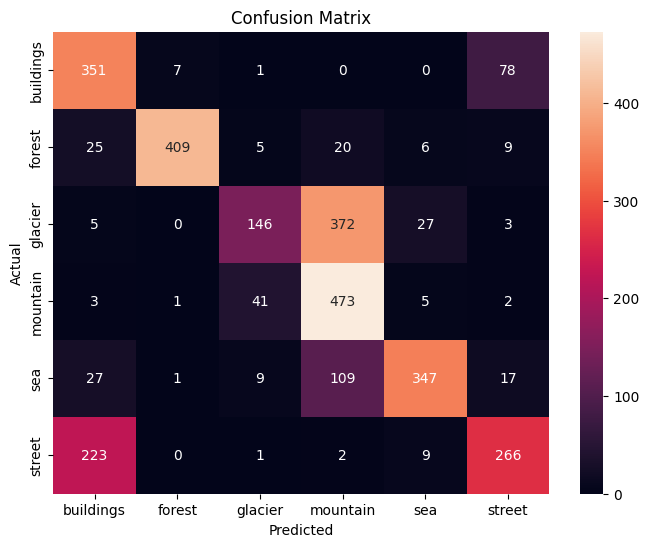

In [ ]:


# Evaluation
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_labels = np.argmax(y_pred, axis=1)

print("Classification Report:\n", classification_report(y_true, y_pred_labels, target_names=test_generator.class_indices.keys()))
cm = confusion_matrix(y_true, y_pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Download dataset
dataset_path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Path to dataset files:", dataset_path)

# Define paths
train_dir = os.path.join(dataset_path, 'seg_train', 'seg_train')
test_dir = os.path.join(dataset_path, 'seg_test', 'seg_test')

# Image parameters
img_height, img_width = 224, 224
batch_size = 32

Path to dataset files: /kaggle/input/intel-image-classification


In [ ]:
# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)



Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [ ]:
# --- Custom CNN Model ---
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

cnn_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])



In [ ]:
# --- Pre-trained MobileNetV2 Model ---
base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(img_height, img_width, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)
pretrained_model = Model(inputs=base_model.input, outputs=predictions)

for layer in base_model.layers:
    layer.trainable = False

pretrained_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Early stopping
early_stop = EarlyStopping(patience=3, restore_best_weights=True)

In [ ]:
# Train Custom CNN
print("\nTraining Custom CNN Model...")
cnn_history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop]
)


Training Custom CNN Model...
Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1339s 4s/step - accuracy: 0.4616 - loss: 1.3948 - val_accuracy: 0.6623 - val_loss: 0.8798
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1306s 4s/step - accuracy: 0.6445 - loss: 0.9415 - val_accuracy: 0.7307 - val_loss: 0.7310
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1344s 4s/step - accuracy: 0.7004 - loss: 0.8186 - val_accuracy: 0.7443 - val_loss: 0.7176
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1288s 4s/step - accuracy: 0.7261 - loss: 0.7556 - val_accuracy: 0.7511 - val_loss: 0.6786
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1295s 4s/step - accuracy: 0.7420 - loss: 0.7099 - val_accuracy: 0.7764 - val_loss: 0.6330
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1336s 4s/step - accuracy: 0.7618 - loss: 0.6644 - val_accuracy: 0.8060 - val_loss: 0.5528
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1274s 4s/step - accuracy: 0.7847 - loss: 0.6138 - val_accuracy: 0.8028 - val_loss: 0.5456
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1267s 4s/step - accu

In [ ]:
# Train Pre-trained Model
print("\nTraining Pre-trained MobileNetV2 Model...")
pretrained_history = pretrained_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop]
)




Training Pre-trained MobileNetV2 Model...
Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 683s 2s/step - accuracy: 0.7095 - loss: 0.7627 - val_accuracy: 0.8823 - val_loss: 0.3265
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 663s 2s/step - accuracy: 0.8596 - loss: 0.3841 - val_accuracy: 0.8877 - val_loss: 0.3131
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 659s 2s/step - accuracy: 0.8795 - loss: 0.3241 - val_accuracy: 0.8994 - val_loss: 0.2862
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 696s 2s/step - accuracy: 0.8825 - loss: 0.3245 - val_accuracy: 0.8955 - val_loss: 0.3004
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 668s 2s/step - accuracy: 0.8883 - loss: 0.2996 - val_accuracy: 0.8966 - val_loss: 0.2967
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 659s 2s/step - accuracy: 0.8884 - loss: 0.2948 - val_accuracy: 0.9026 - val_loss: 0.2845
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 664s 2s/step - accuracy: 0.8815 - loss: 0.3127 - val_accuracy: 0.8994 - val_loss: 0.2863
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 697s 2s/step -


Testing Custom CNN Model...
94/94 ━━━━━━━━━━━━━━━━━━━━ 83s 882ms/step
Custom CNN Classification Report:
               precision    recall  f1-score   support

   buildings       0.78      0.85      0.81       437
      forest       0.94      0.97      0.96       474
     glacier       0.81      0.81      0.81       553
    mountain       0.80      0.75      0.77       525
         sea       0.86      0.78      0.82       510
      street       0.84      0.88      0.86       501

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000



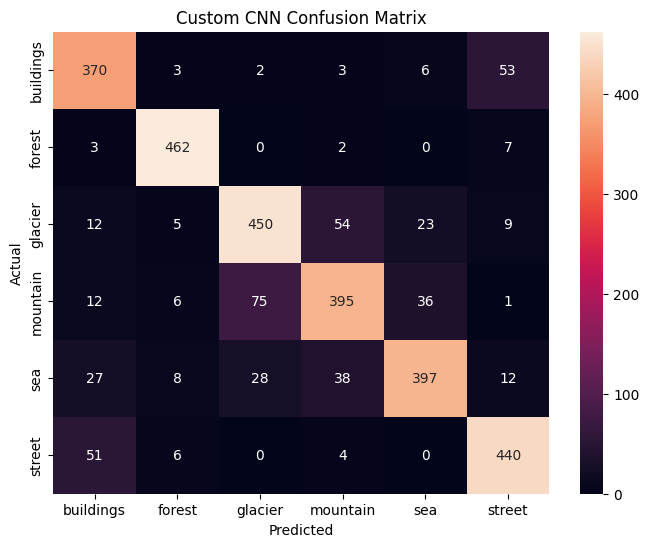

In [ ]:
# --- Test Custom CNN Model ---
print("\nTesting Custom CNN Model...")
y_true = test_generator.classes
y_pred_cnn = cnn_model.predict(test_generator)
y_pred_cnn_labels = np.argmax(y_pred_cnn, axis=1)

print("Custom CNN Classification Report:\n",
      classification_report(y_true, y_pred_cnn_labels, target_names=test_generator.class_indices.keys()))
cm_cnn = confusion_matrix(y_true, y_pred_cnn_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt="d", xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title("Custom CNN Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()




Testing Pre-trained MobileNetV2 Model...
94/94 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step
Pre-trained MobileNetV2 Classification Report:
               precision    recall  f1-score   support

   buildings       0.90      0.93      0.92       437
      forest       0.99      0.99      0.99       474
     glacier       0.84      0.83      0.84       553
    mountain       0.85      0.83      0.84       525
         sea       0.92      0.96      0.94       510
      street       0.93      0.92      0.93       501

    accuracy                           0.90      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.90      0.90      0.90      3000



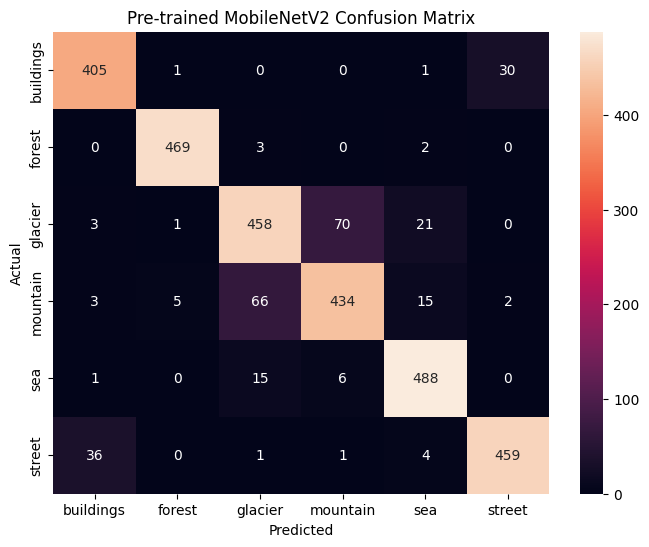

In [ ]:
# --- Test Pre-trained Model ---
print("\nTesting Pre-trained MobileNetV2 Model...")
y_pred_pretrained = pretrained_model.predict(test_generator)
y_pred_pretrained_labels = np.argmax(y_pred_pretrained, axis=1)

print("Pre-trained MobileNetV2 Classification Report:\n",
      classification_report(y_true, y_pred_pretrained_labels, target_names=test_generator.class_indices.keys()))
cm_pretrained = confusion_matrix(y_true, y_pred_pretrained_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_pretrained, annot=True, fmt="d", xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title("Pre-trained MobileNetV2 Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 25s 25s/step


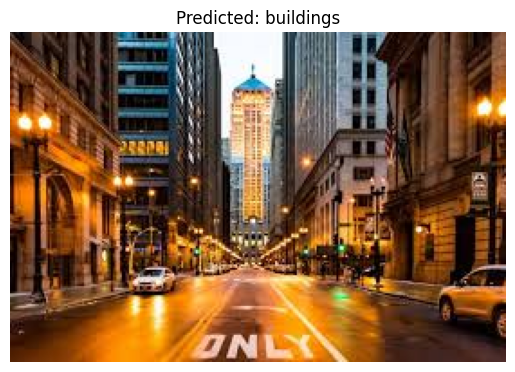

In [ ]:

from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Path to your test image
img_path = '/content/testimage.jpg'  # Replace with your actual image path

# Load and preprocess the image
img = image.load_img(img_path, target_size=(224, 224))  # Adjust size to your model input
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  # Normalize if your model was trained on normalized data

# Make prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

# Class names used during training
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']  # Replace with your actual class labels

# Show image and prediction
plt.imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB))
plt.title(f"Predicted: {class_names[predicted_class]}")
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


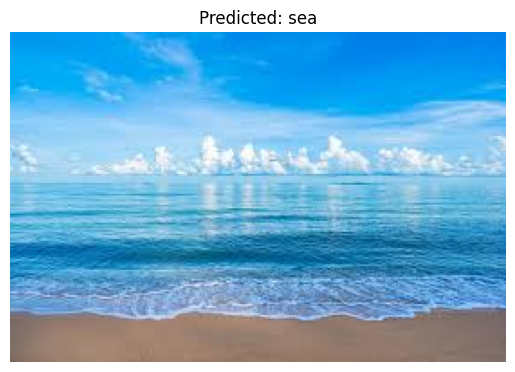

In [10]:

from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Path to your test image
img_path = '/content/testimage2.jpg'  # Replace with your actual image path

# Load and preprocess the image
img = image.load_img(img_path, target_size=(224, 224))  # Adjust size to your model input
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  # Normalize if your model was trained on normalized data

# Make prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

# Class names used during training
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']  # Replace with your actual class labels

# Show image and prediction
plt.imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB))
plt.title(f"Predicted: {class_names[predicted_class]}")
plt.axis('off')
plt.show()
